In [ ]:
import pandas as pd
import numpy as np
from ta.trend import *
from ta.momentum import *
from ta.volume import *
from ta.volatility import *
from ta.others import *
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


path = "C:/Users/yhsol/Downloads/AMZN_alpha_1min_2024-05_to_2025-05 (1).csv"
df = pd.read_csv(path)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

In [ ]:

df['RSI'] = RSIIndicator(df['Close']).rsi().shift(1)

bb = BollingerBands(df['Close'])
df['Bollinger_MAVG'] = bb.bollinger_mavg().shift(1)


df['PSAR'] = PSARIndicator(df['High'], df['Low'], df['Close']).psar().shift(1)


ma = df['Close'].rolling(window=20).mean()
df['Envelope_upper'] = (ma * 1.025).shift(1)

df['%R'] = WilliamsRIndicator(df['High'], df['Low'], df['Close']).williams_r().shift(1)
df['MACD'] = MACD(df['Close']).macd().shift(1)
df['OBV'] = OnBalanceVolumeIndicator(df['Close'], df['Volume']).on_balance_volume().shift(1)
df['EMA'] = EMAIndicator(df['Close']).ema_indicator().shift(1)

# VWAP approximation (simple version)
df['VWAP'] = (df['Volume'] * (df['High'] + df['Low'] + df['Close']) / 3).cumsum() / df['Volume'].cumsum()
df['VWAP'] = df['VWAP'].shift(1)

df['ATR'] = AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range().shift(1)
df['IBS'] = ((df['Close'] - df['Low']) / (df['High'] - df['Low'])).shift(1)
df['PPO'] = PercentagePriceOscillator(df['Close']).ppo().shift(1)
df['CMF'] = ChaikinMoneyFlowIndicator(df['High'], df['Low'], df['Close'], df['Volume']).chaikin_money_flow().shift(1)
df['Stochastic'] = StochasticOscillator(df['High'], df['Low'], df['Close']).stoch().shift(1)
df['ADX'] = ADXIndicator(df['High'], df['Low'], df['Close']).adx().shift(1)
df['Ichimoku'] = IchimokuIndicator(df['High'], df['Low']).ichimoku_a().shift(1)
df['StdDev'] = df['Close'].rolling(window=14).std().shift(1)
df['AO'] = AwesomeOscillatorIndicator(df['High'], df['Low']).awesome_oscillator().shift(1)
df['AD'] = AccDistIndexIndicator(df['High'], df['Low'], df['Close'], df['Volume']).acc_dist_index().shift(1)
df['CCI'] = CCIIndicator(df['High'], df['Low'], df['Close']).cci().shift(1)
df['RVI'] = df['Close'].diff(4).shift(1)  # Simplified RVI
df['ROC'] = ROCIndicator(df['Close']).roc().shift(1)


c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\ta\trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


In [17]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'Bollinger_MAVG',
       'PSAR', 'Envelope_upper', '%R', 'MACD', 'OBV', 'EMA', 'VWAP', 'ATR',
       'IBS', 'PPO', 'CMF', 'Stochastic', 'ADX', 'Ichimoku', 'StdDev', 'AO',
       'AD', 'CCI', 'RVI', 'ROC'],
      dtype='object')

In [ ]:
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

features = [
    'RSI', 'Bollinger_MAVG', 'PSAR', 'Envelope_upper', '%R', 'MACD', 'OBV', 'EMA', 
    'VWAP', 'ATR', 'IBS', 'PPO', 'CMF', 'Stochastic', 'ADX', 'Ichimoku', 'StdDev', 
    'AO', 'AD', 'CCI', 'RVI', 'ROC'
]

df.dropna(subset=features + ['Target'], inplace=True)

In [ ]:

X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [22]:
sfs = SFS(model,
          k_features='best',
          forward=True,
          floating=False,
          scoring='accuracy',
          cv=5,
          n_jobs=-1)

sfs.fit(X_train, y_train)

SequentialFeatureSelector(estimator=RandomForestClassifier(random_state=42),
                          k_features=(1, 22), n_jobs=-1, scoring='accuracy')

In [ ]:
selected_features = list(sfs.k_feature_names_)

model.fit(X_train[selected_features], y_train)
preds = model.predict(X_test[selected_features])
acc = accuracy_score(y_test, preds)


print("Selected Features:", selected_features)
print("Test Accuracy:", acc)

Selected Features: ['RVI']
Test Accuracy: 0.5157860404435747


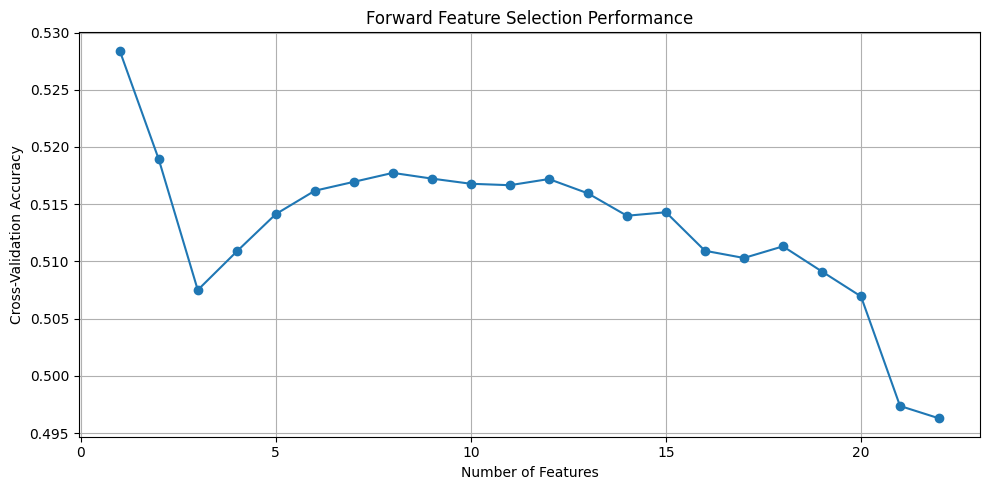

In [ ]:
import matplotlib.pyplot as plt


metric_dict = sfs.get_metric_dict()
k_feat = list(metric_dict.keys())
scores = [metric_dict[k]['avg_score'] for k in k_feat]

plt.figure(figsize=(10, 5))
plt.plot(k_feat, scores, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Forward Feature Selection Performance')
plt.grid(True)
plt.tight_layout()
plt.show()
